In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import mdsine2 as md2
from mdsine2.names import STRNAMES
import pickle
from sklearn import linear_model as lm

In [ ]:
npzfile = np.load("datasets/synthetic/glv.npz")
npzfile

In [ ]:
gr = npzfile["growth_rates"]
ints = npzfile["interactions"]

In [ ]:
plt.imshow(ints, cmap="coolwarm", vmin=-np.max(np.abs(ints)), vmax=np.max(np.abs(ints)))
plt.colorbar()

In [ ]:
plt.imshow(np.sign(ints), cmap="coolwarm")

In [116]:
with open("datasets/synthetic/output/reads_25000/trial_0/low_noise/mdsine2/simulated-low/mcmc.pkl", "rb") as file:
    mcmc = pickle.load(file)

In [117]:
md2.summary(mcmc.graph[STRNAMES.SELF_INTERACTION_VALUE])["mean"]

array([9.67908249e-06, 2.15909953e-05, 3.77577814e-05, 1.69993017e-05,
       2.06183595e-05, 2.47532282e-05, 1.65739030e-05, 3.43050577e-05,
       1.85628813e-05, 4.44545764e-05])

In [118]:
gr_est = md2.summary(mcmc.graph[STRNAMES.GROWTH_VALUE])["mean"]

In [119]:
mcmc

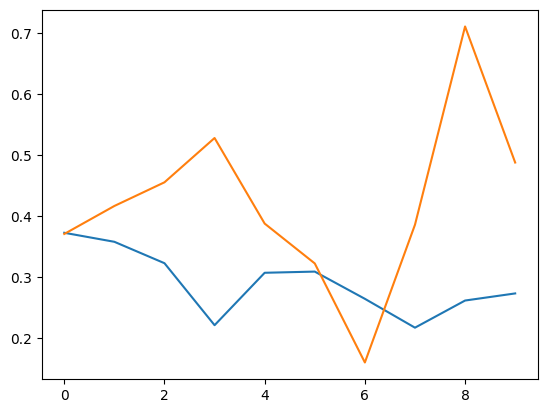

In [120]:
plt.plot(gr)
plt.plot(gr_est)

In [53]:
ints_est = md2.summary(mcmc.graph[STRNAMES.INTERACTIONS_OBJ].get_trace_from_disk())["mean"]-np.diag(md2.summary(mcmc.graph[STRNAMES.SELF_INTERACTION_VALUE].get_trace_from_disk())["mean"])

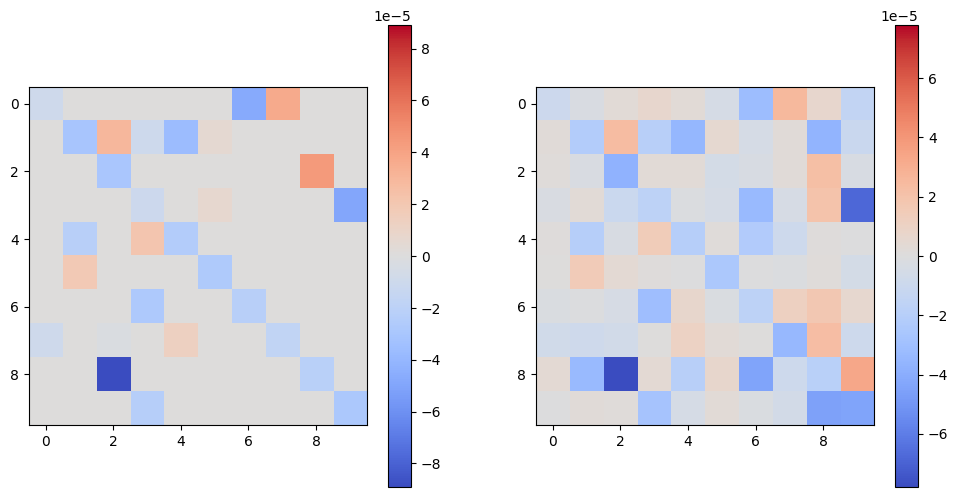

In [54]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

im1 = ax[0].imshow(ints, cmap="coolwarm", vmin=-np.max(np.abs(ints)), vmax=np.max(np.abs(ints)))
fig.colorbar(im1)

im2 = ax[1].imshow(ints_est, cmap="coolwarm", vmin=-np.max(np.abs(ints_est)), vmax=np.max(np.abs(ints_est)))
fig.colorbar(im2)

In [87]:
np.nan_to_num(np.log(md2.generate_interation_bayes_factors_posthoc(mcmc)), posinf=0, neginf=0).

np.float64(-3.8038041783102137)

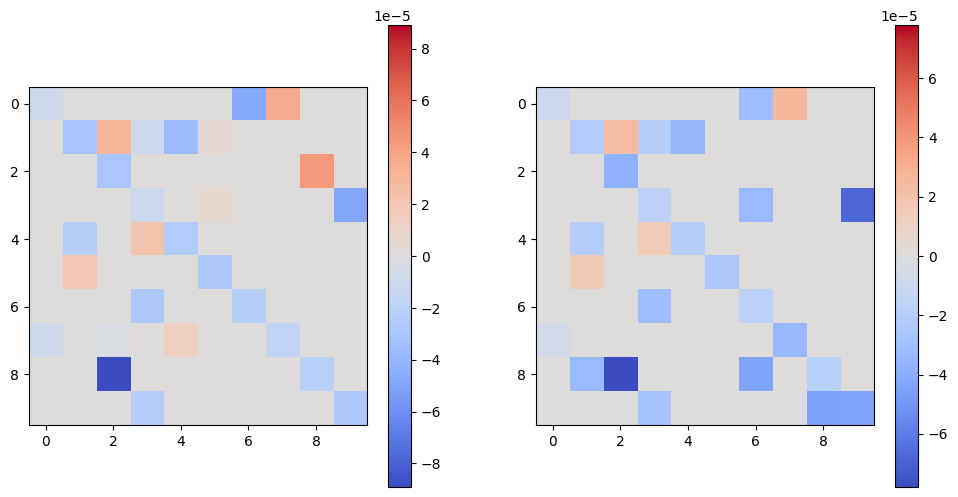

In [103]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

im1 = ax[0].imshow(ints, cmap="coolwarm", vmin=-np.max(np.abs(ints)), vmax=np.max(np.abs(ints)))
fig.colorbar(im1)

im2 = ax[1].imshow(ints_est*(md2.generate_interation_bayes_factors_posthoc(mcmc, )>10)+np.diag(np.diag(ints_est)), cmap="coolwarm", vmin=-np.max(np.abs(ints_est)), vmax=np.max(np.abs(ints_est)))
fig.colorbar(im2)

In [55]:
from scipy.stats import spearmanr, pearsonr

In [122]:
spearmanr(gr, gr_est)

SignificanceResult(statistic=np.float64(-0.2727272727272727), pvalue=np.float64(0.4458383415427516))

In [128]:
mcmc.graph[STRNAMES.PROCESSVAR].get_trace_from_disk().mean()

np.float64(0.19012891907758775)

In [221]:
spearmanr((ints).flatten(), (ints_est).flatten())

SignificanceResult(statistic=np.float64(0.6705115835884452), pvalue=np.float64(2.3304447465201692e-14))

In [220]:
spearmanr((ints-np.diag(np.diag(ints))).flatten(), (ints_est-np.diag(np.diag(ints_est))).flatten())

SignificanceResult(statistic=np.float64(0.5543593318285278), pvalue=np.float64(2.1797327133333015e-09))

In [124]:
spearmanr((ints-np.diag(np.diag(ints))).flatten(), ((ints_est-np.diag(np.diag(ints_est)))*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10)).flatten())

SignificanceResult(statistic=np.float64(0.7491818409784313), pvalue=np.float64(3.1246584512034493e-19))

In [223]:
spearmanr((ints).flatten(), ((ints_est-np.diag(np.diag(ints_est)))*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10)+np.diag(np.diag(ints_est))).flatten())

SignificanceResult(statistic=np.float64(0.8261965840198164), pvalue=np.float64(3.6713403725084354e-26))

In [96]:
pearsonr((ints-np.diag(np.diag(ints))).flatten(), (ints_est-np.diag(np.diag(ints_est))).flatten())

PearsonRResult(statistic=np.float64(0.739713524899705), pvalue=np.float64(1.4899413981516348e-18))

In [101]:
pearsonr((ints-np.diag(np.diag(ints))).flatten(), ((ints_est-np.diag(np.diag(ints_est)))*(md2.generate_interation_bayes_factors_posthoc(mcmc)>10)).flatten())

PearsonRResult(statistic=np.float64(0.7917978803292621), pvalue=np.float64(1.0495211828973022e-22))

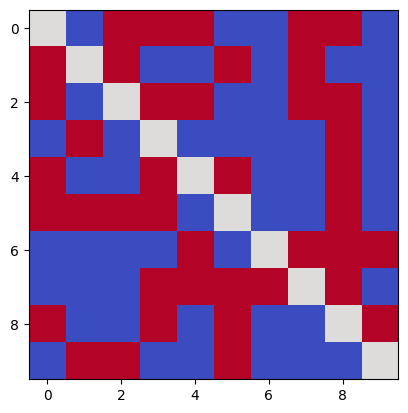

In [25]:
plt.imshow(np.sign(ints_est), cmap="coolwarm")

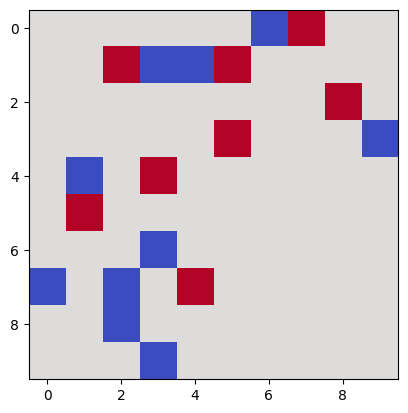

In [37]:
plt.imshow(np.sign(ints)+np.eye(10), cmap="coolwarm")

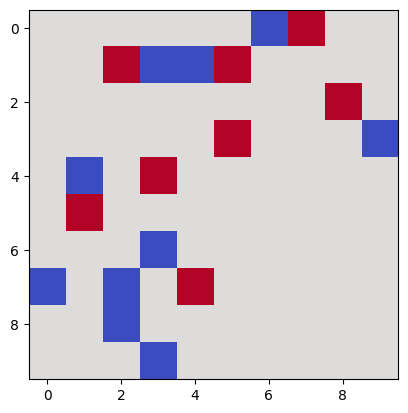

In [44]:
plt.imshow(np.sign(ints)*(md2.generate_interation_bayes_factors_posthoc(mcmc)>1e-1), cmap="coolwarm")

---

In [133]:
with open("datasets/synthetic/data/trial_0/reads_25000/noise_low/subjset.pkl", "rb") as file:
    subjset = pickle.load(file)

In [154]:
list(subjset[0].qpcr.values())[0].data.mean()

np.float64(77189.50018967286)

In [172]:
t = subjset[0].times

In [1]:
plt.plot(subjset[0].matrix()["abs"].T)
plt.plot(X[:26]/25000, "--")

NameError: name 'plt' is not defined

In [267]:
reads = np.array(list(subjset[0].reads.values()))
qpcr = np.array([i.data.mean() for i in subjset[0].qpcr.values()])

X = reads*qpcr.reshape((-1,1))

dX = np.diff(X, axis=0)
X = X[:-1]

for i in range(1, 10):
    reads = np.array(list(subjset[i].reads.values()))
    qpcr = np.array([k.data.mean() for k in subjset[i].qpcr.values()])

    x = reads*qpcr.reshape((-1,1))
    dx = np.diff(x, axis=0)

    X = np.concatenate([X, x[:-1]], axis=0)
    dX = np.concatenate([dX, dx], axis=0)

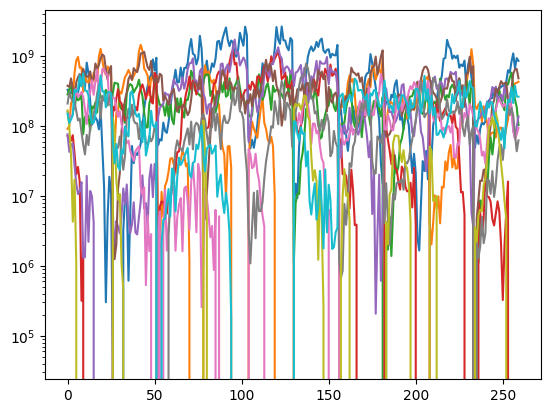

In [268]:
plt.plot(X)
plt.yscale("log")

In [269]:
reg = lm.LinearRegression(fit_intercept=False)

In [270]:
Aest = np.zeros((10,11))

for i in range(10):
    feats = np.hstack([X[i*26:(i+1)*26,[i]], X[i*26:(i+1)*26,[i]]*X[i*26:(i+1)*26]])
    reg.fit(feats, dX[i*26:(i+1)*26,i]/np.diff(t))
    Aest[i] = reg.coef_

In [271]:
reg.coef_

array([ 9.48773575e-01, -1.31326100e-11,  3.18133436e-10,  7.33752428e-10,
        2.40148463e-08, -3.55152920e-09,  2.24261245e-10,  7.63313390e-10,
        1.79321841e-10,  1.31121812e-09, -3.72888731e-09])

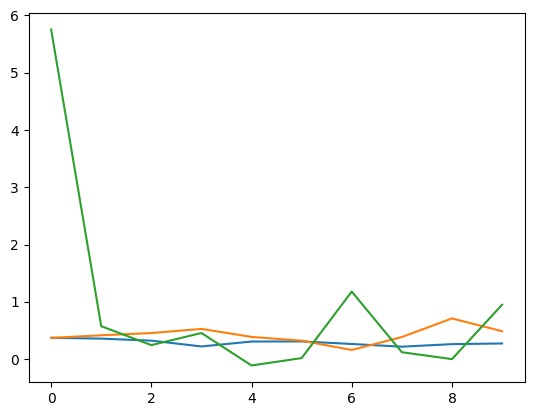

In [272]:
plt.plot(gr)
plt.plot(gr_est)
plt.plot(Aest[:,0])

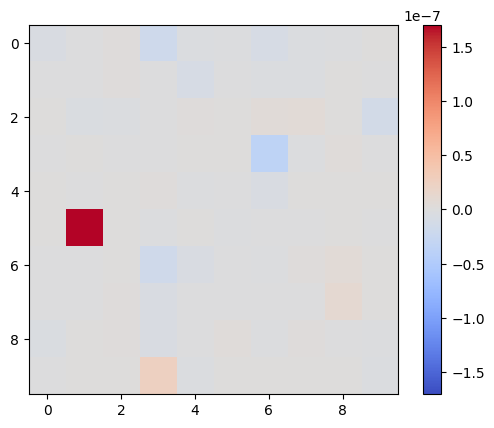

In [273]:
plt.imshow(Aest[:,1:], cmap="coolwarm", vmin=-np.max(np.abs(Aest[:,1:])), vmax=np.max(np.abs(Aest[:,1:])))
plt.colorbar()

In [224]:
spearmanr(ints.flatten(), Aest[:,1:].flatten())

SignificanceResult(statistic=np.float64(0.11891462709197459), pvalue=np.float64(0.23864425088852864))